In [1]:
import numpy as np
import pulp as pulp
from pulp import *
from simulation import *
from lp_solver import *
from update_policy import *
from generate_parameters import *
from filling_policy import *
from LP_indices_tie_solving import *
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import joblib
from joblib import Parallel, delayed

In [2]:
T = 30
n = 10
myN = np.arange(10,60,10)
alpha = 0.5
repeat = 8

In [3]:
# Load the saved results
z = np.load('tie_solving_result.npz',allow_pickle=True)
full_data = np.array(list(z['arr_0']))

In [4]:
#LP_indices scores and variations
lp_indices = full_data[0]
#reward priority scores and variations
reward_prio = full_data[1]
# starting from full_data[2] are fixed priorities scores and variations
fixed_prio = full_data[2:]

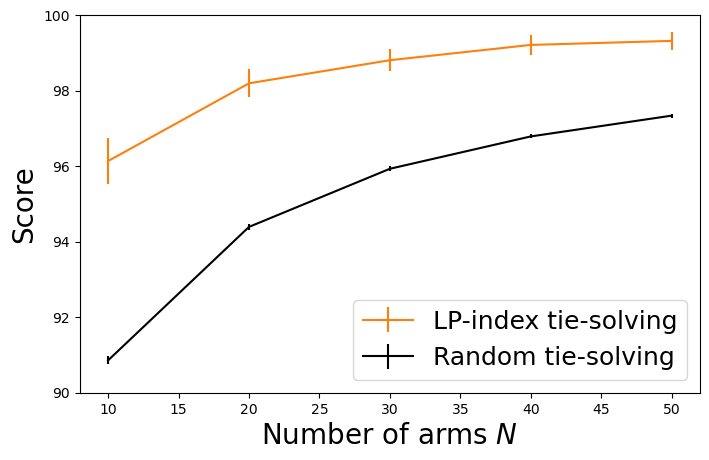

In [9]:
figure(num=None, figsize=(8, 5), dpi=100, facecolor='w', edgecolor='k')
plt.rc('legend',fontsize= 18)

prop_cycle = plt.rcParams['axes.prop_cycle']
colors_default = prop_cycle.by_key()['color']


colors = {'greedy':colors_default[6], 'LP-infinite':colors_default[0],'myopic':colors_default[5],
          'LP-index':colors_default[1], 'LP-update':colors_default[2],'upperbound':colors_default[4],
          'fixed_order1':colors_default[7],'fixed_order2':colors_default[8],'fixed_order3':colors_default[9],
         'solve_LP':colors_default[3],'load_data':colors_default[8],'compute_index':colors_default[9]}

myN = np.arange(10,60,10)

plt.errorbar(myN, lp_indices[0],xerr=0,yerr=lp_indices[1],color=colors['LP-index'],
            label="LP-index tie-solving")
#plt.errorbar(myN, reward_prio[0],xerr=0,yerr=reward_prio[1],color=colors['greedy'],
#             label="reward priority")



#plt.fill_between(myN, np.max(fixed_prio[:,0],0), np.min(fixed_prio[:,0],0), linestyle=':', color='grey', alpha=0.5)
#plt.plot(myN, np.mean(fixed_prio[:,0],0), linestyle='--', color='k', lw=2, label='Random tie-solving')
    #plt.plot(myN,priority_score_mean,'-*')
mean_fixed_prio = np.mean(fixed_prio[:,0],0)
error_fixed_prio = 3*np.sqrt(np.var(fixed_prio[:,0],0)/len(fixed_prio))
plt.errorbar(myN, mean_fixed_prio, error_fixed_prio, color='k', label='Random tie-solving')

plt.xlabel(r'Number of arms $N$',fontsize=20)
plt.ylabel('Score',fontsize= 20)
plt.ylim(90,100)
plt.legend(loc = 'lower right')
plt.savefig("tie-solving-more.pdf",bbox_inches='tight')

# Run the following code to compute more fixed priorities

In [11]:
nb_of_more_prios = 10


z = np.load('tie_solving_paras.npz',allow_pickle=True)
paras = list(z['arr_0'])
z = np.load('tie_solving_prios.npz',allow_pickle=True)
priorities = list(z['arr_0'])
z = np.load('tie_solving_result.npz',allow_pickle=True)
full_data = list(z['arr_0'])
print(str(len(full_data)-2)+" prios computed, "+"let us compute "+str(nb_of_more_prios)+" more!" )

STOP
for _ in tqdm(range(nb_of_more_prios)):
    one_prio = np.random.permutation(n)
    priorities.append(one_prio)
    prio_score_mean,prio_score_var = test_all_paras_with_one_prio(T,n,myN,alpha,one_prio,paras,repeat)
    full_data.append([prio_score_mean,prio_score_var])
np.savez('tie_solving_prios.npz',priorities)
np.savez('tie_solving_result.npz',full_data)

100 prios computed, let us compute 10 more!


NameError: name 'STOP' is not defined

# Testing with a SINGLE model and with 100 fixed priority policies. 

In [12]:
z = np.load('tie_solving_paras.npz',allow_pickle=True)
paras = list(z['arr_0']) # we fixed the model to be "paras[0]"
np.random.seed(0) # We fixed the seed
T, n, alpha = 30, 10, 0.5

def load_score_prio(para_nb, nb_replicas=100):
    """
    Returns an array of "nb_replicas" scores of the LP priority index
    """
    filename = 'fixed_prio_one_model_{}.npy'.format(para_nb)
    try:
        fixed_prio = list(np.load(filename))
    except Exception as e:
        print(e)
        fixed_prio = []
    if len(fixed_prio) < nb_replicas:
        for i in range(len(fixed_prio), nb_replicas):
            one_prio = np.random.permutation(n)
            value_one_prio = test_one_para_with_one_prio(T,n,[20],alpha,one_prio,paras,para_nb,repeat=100)[0]
            fixed_prio.append(value_one_prio)
            print(i, one_prio, value_one_prio)
        np.save(filename,np.array(fixed_prio))
    return np.array(fixed_prio)


fixed_prio = load_score_prio(3)

(array([ 1.,  4.,  3.,  2.,  1.,  4.,  1.,  7., 12.,  8., 10., 11., 10.,
         5.,  6.,  4.,  1.,  5.,  3.,  2.]),
 array([92.20733461, 92.51249016, 92.8176457 , 93.12280124, 93.42795678,
        93.73311232, 94.03826786, 94.34342341, 94.64857895, 94.95373449,
        95.25889003, 95.56404557, 95.86920111, 96.17435665, 96.4795122 ,
        96.78466774, 97.08982328, 97.39497882, 97.70013436, 98.0052899 ,
        98.31044544]),
 <BarContainer object of 20 artists>)

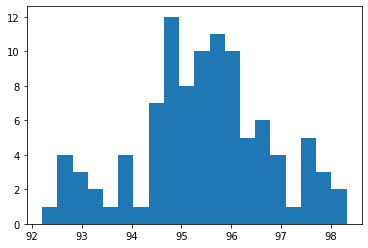

In [5]:
plt.hist(fixed_prio, bins=20)

## Comparaison fixed-priority vs LP-index

In [13]:
from enum import Enum
class policies(Enum):
    LP_INDEX = 1
    FIXED_PRIO = 2
    UPPER_BOUND = 3
    LOWER_BOUND = 4

def value_policy(para_nb, policy, N=10, one_prio=None):
    """
    Does one simulation to obtain the value of a given policy on a given model.
    - para_nb is the ID of the model
    - policy should be a member "policies"
    - N = number of arms
    - one_prio is the ID of the priority order to use when policy = policies.FIXED_PRIO
    """
    P0,P1,R0,R1,init,alpha = paras[para_nb]
    if one_prio is None:
        one_prio = np.random.permutation(len(P0))
    else:
        one_prio = priorities[one_prio]
    N = 20 
    states = give_states(n,N,init)
    true_init = states/N
    M = int(round(alpha*N))
    if policy == policies.LP_INDEX:
        return filling_sim(P0,P1,R0,R1,T,states,M)
    if policy == policies.FIXED_PRIO:
        return fix_order_sim(P0,P1,R0,R1,T,states,M,one_prio)
    if policy == policies.UPPER_BOUND:
        return relax_upperbound(P0,P1,R0,R1,T,true_init,alpha)
    if policy == policies.LOWER_BOUND:
        return relax_lowerbound(P0,P1,R0,R1,T,true_init,alpha)
    return -100

def values_policy(para_nb, policy, N=10, one_prio=None, number_of_replicas=10):
    """
    Return "number_of_replicas" of the above value
    """
    return [value_policy(para_nb, policy, N, one_prio) for i in range(number_of_replicas)]

def average_score(para_nb, policy, N=10, one_prio=None, number_of_replicas=100):
    filename = 'data/one_model_para_nb{}_policy{}_N{}_prio{}.npy'.format(para_nb, policy, N, one_prio)
    try:
        score = list(np.load(filename))
    except FileNotFoundError:
        simulated_values = values_policy(para_nb, policy, N, one_prio, number_of_replicas)
        upper = value_policy(para_nb, policies.UPPER_BOUND)
        lower = value_policy(para_nb, policies.LOWER_BOUND)
        rescaled_values = 100*(simulated_values-lower)/(upper-lower)
        score = [np.mean(rescaled_values), np.std(rescaled_values)/np.sqrt(number_of_replicas)]
        
        np.save(filename, score)
    except Exception as e:
        print(e)      
    return score

print('upper:', value_policy(0, policies.UPPER_BOUND))
one_prio = np.random.permutation(len(P0))
print('fixed prio:', values_policy(0, policies.FIXED_PRIO, 20, 0))

upper: 1.4754402907717734


NameError: name 'P0' is not defined

In [14]:
nb_models = 100
nb_replicas = 5
scores = np.empty(shape=(nb_replicas, nb_models, 2, 2))
scores[:] = np.nan
for one_prio in range(nb_replicas):
    for model in range(nb_models):
        score_LPindex = average_score(model, policies.LP_INDEX, N=20, number_of_replicas=100)
        score_LPprio = average_score(model, policies.FIXED_PRIO, N=20, one_prio = one_prio, number_of_replicas=100)
        scores[one_prio, model, :,:] = np.array([score_LPprio, score_LPindex])
        print('\r',model, one_prio, score_LPprio, score_LPindex, end='')


 99 4 [93.52596676839808, 0.6673189151843496] [97.83485144407926, 0.6231626950931777]]][96.39483820004149, 0.4830271578335351] [97.36476056286547, 0.5466702919030297][92.5070167947643, 0.4793234927162322] [99.58068113011741, 0.4064815919328981][96.58059447763468, 0.41303382795930343] [97.88446100782676, 0.3775452132370028]

(array([ 1.,  2.,  4.,  6.,  9., 27., 23., 13., 11.,  4.]),
 array([ 94.66740729,  95.23459134,  95.80177538,  96.36895943,
         96.93614347,  97.50332752,  98.07051156,  98.6376956 ,
         99.20487965,  99.77206369, 100.33924774]),
 <BarContainer object of 10 artists>)

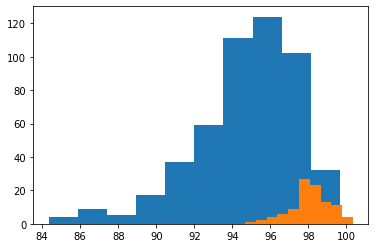

In [15]:
plt.hist(scores[:,:,0,0].reshape(-1), label='LP-prio')
plt.hist(scores[0,:,1,0], label='LP-index')

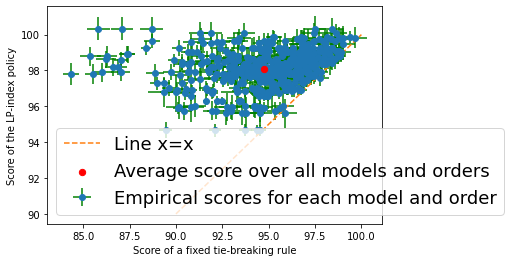

In [16]:
nb_fixed = 5 # number of fixed policies considered
x = scores[:nb_fixed,:,0,0].reshape(-1)     # Score of fixed prio
y = scores[:nb_fixed,:,1,0].reshape(-1)     # Score of LP index
xerr = scores[:nb_fixed,:,0,1].reshape(-1)  # Conf interval fixed prio
yerr = scores[:nb_fixed,:,1,1].reshape(-1)  # Conf interval LP index
plt.errorbar(x, y, xerr, yerr, fmt='o', ecolor='g', capthick=2, label='Empirical scores for each model and order')

plt.scatter([np.mean(x)],[np.mean(y)], s=[40], color='r', zorder=10, label='Average score over all models and orders')
plt.plot([90,100],[90,100],'--', label='Line x=x')
plt.ylabel('Score of the LP-index policy')
plt.xlabel('Score of a fixed tie-breaking rule')
plt.legend(loc='best')
#plt.ylim(85,101)
#plt.savefig('tie-solving_fixedVSlpindex.pdf', bbox_inches='tight')

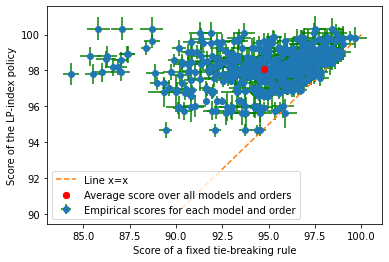

In [41]:
nb_fixed = 5 # number of fixed policies considered
x = scores[:nb_fixed,:,0,0].reshape(-1)     # Score of fixed prio
y = scores[:nb_fixed,:,1,0].reshape(-1)     # Score of LP index
xerr = scores[:nb_fixed,:,0,1].reshape(-1)  # Conf interval fixed prio
yerr = scores[:nb_fixed,:,1,1].reshape(-1)  # Conf interval LP index
plt.errorbar(x, y, xerr, yerr, fmt='o', ecolor='g', capthick=2, label='Empirical scores for each model and order')

plt.scatter([np.mean(x)],[np.mean(y)], s=[40], color='r', zorder=10, label='Average score over all models and orders')
plt.plot([90,100],[90,100],'--', label='Line x=x')
plt.ylabel('Score of the LP-index policy')
plt.xlabel('Score of a fixed tie-breaking rule')
plt.legend(loc='best')
#plt.ylim(85,101)
plt.savefig('tie-solving_fixedVSlpindex.pdf', bbox_inches='tight')

In [ ]:
for i in np.argsort(y-x)[0:10]:
    j,m = np.unravel_index(i, (5,100))
    print((x-y)[i], xerr[i], yerr[i])
